# Exploratory Data Analysis - Animals-10 Dataset

Analysis of the Animals-10 dataset used for training the image classifier in the animal recognition pipeline.

## 1. Dataset Download and Loading

In [ ]:
import os
import random
import warnings
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision import transforms
from collections import Counter

warnings.filterwarnings("ignore", category=UserWarning)

# Dataset originally is in Italian
TRANSLATE = {
    "cane": "dog", 
    "cavallo": "horse", 
    "elefante": "elephant",
    "farfalla": "butterfly", 
    "gallina": "chicken", 
    "gatto": "cat",
    "mucca": "cow", 
    "pecora": "sheep", 
    "ragno": "spider",
    "scoiattolo": "squirrel",
}

In [ ]:
dataset_path = kagglehub.dataset_download("alessiocorrado99/animals10")
raw_img_dir = os.path.join(dataset_path, "raw-img")
print(f"Dataset path: {raw_img_dir}")
print(f"Class folders: {sorted(os.listdir(raw_img_dir))}")

Dataset path: C:\Users\marko\.cache\kagglehub\datasets\alessiocorrado99\animals10\versions\2\raw-img
Class folders: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


In [ ]:
image_data = []
for folder in sorted(os.listdir(raw_img_dir)):
    folder_path = os.path.join(raw_img_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    english_name = TRANSLATE.get(folder, folder)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        if os.path.isfile(fpath):
            image_data.append({"path": fpath, "class": english_name})

df = pd.DataFrame(image_data)
print(f"Total images: {len(df)}")
print(f"\nPer-class counts:")
for cls, cnt in df["class"].value_counts().sort_index().items():
    print(f"  {cls}: {cnt}")

Total images: 26179

Per-class counts:
  butterfly: 2112
  cat: 1668
  chicken: 3098
  cow: 1866
  dog: 4863
  elephant: 1446
  horse: 2623
  sheep: 1820
  spider: 4821
  squirrel: 1862


## 2. Class Distribution

C:\Users\marko\AppData\Local\Temp\ipykernel_7040\3962457546.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")


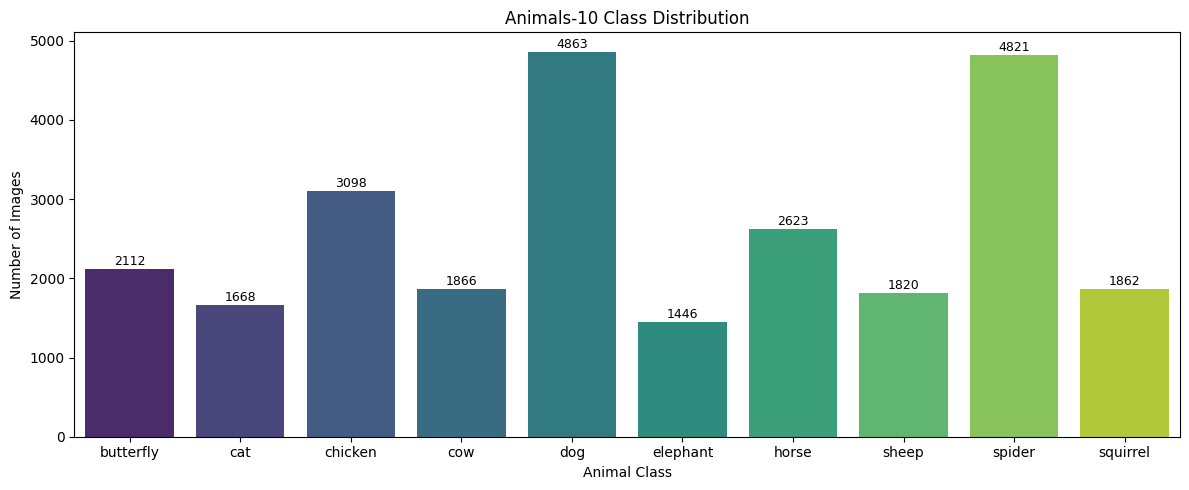


Min class: elephant (1446)
Max class: dog (4863)
Imbalance ratio (max/min): 3.4x


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
counts = df["class"].value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
ax.set_xlabel("Animal Class")
ax.set_ylabel("Number of Images")
ax.set_title("Animals-10 Class Distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nMin class: {counts.idxmin()} ({counts.min()})")
print(f"Max class: {counts.idxmax()} ({counts.max()})")
print(f"Imbalance ratio (max/min): {counts.max() / counts.min():.1f}x")

## 3. Sample Images

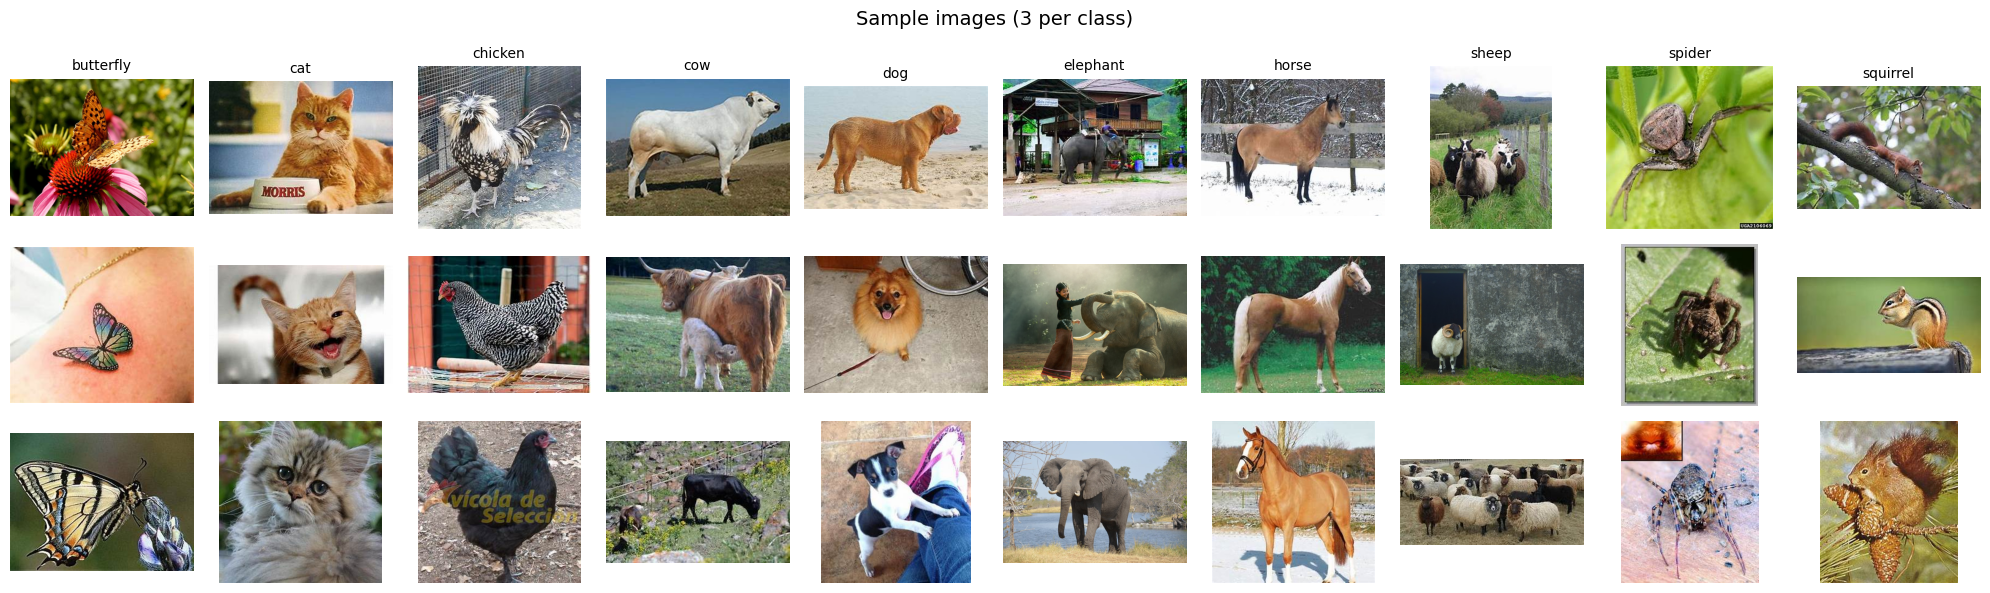

In [5]:
classes = sorted(df["class"].unique())
fig, axes = plt.subplots(3, 10, figsize=(20, 6))

rng = random.Random(67)
for col, cls in enumerate(classes):
    cls_paths = df[df["class"] == cls]["path"].tolist()
    samples = rng.sample(cls_paths, min(3, len(cls_paths)))
    for row, path in enumerate(samples):
        try:
            img = Image.open(path).convert("RGB")
            axes[row, col].imshow(img)
        except Exception:
            axes[row, col].text(0.5, 0.5, "ERR", ha="center", va="center")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(cls, fontsize=10)

plt.suptitle("Sample images (3 per class)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Image Statistics

In [6]:
# Collect width, height, and mean pixel value for each image
widths, heights, mean_pixels, img_classes = [], [], [], []

for _, row in df.iterrows():
    try:
        img = Image.open(row["path"])
        w, h = img.size
        widths.append(w)
        heights.append(h)
        mean_pixels.append(np.array(img.convert("RGB")).mean())
        img_classes.append(row["class"])
    except Exception:
        pass

stats_df = pd.DataFrame({
    "width": widths, "height": heights,
    "aspect_ratio": [w / h for w, h in zip(widths, heights)],
    "mean_pixel": mean_pixels, "class": img_classes,
})
print(f"Successfully loaded {len(stats_df)} / {len(df)} images for stats")

Successfully loaded 26179 / 26179 images for stats


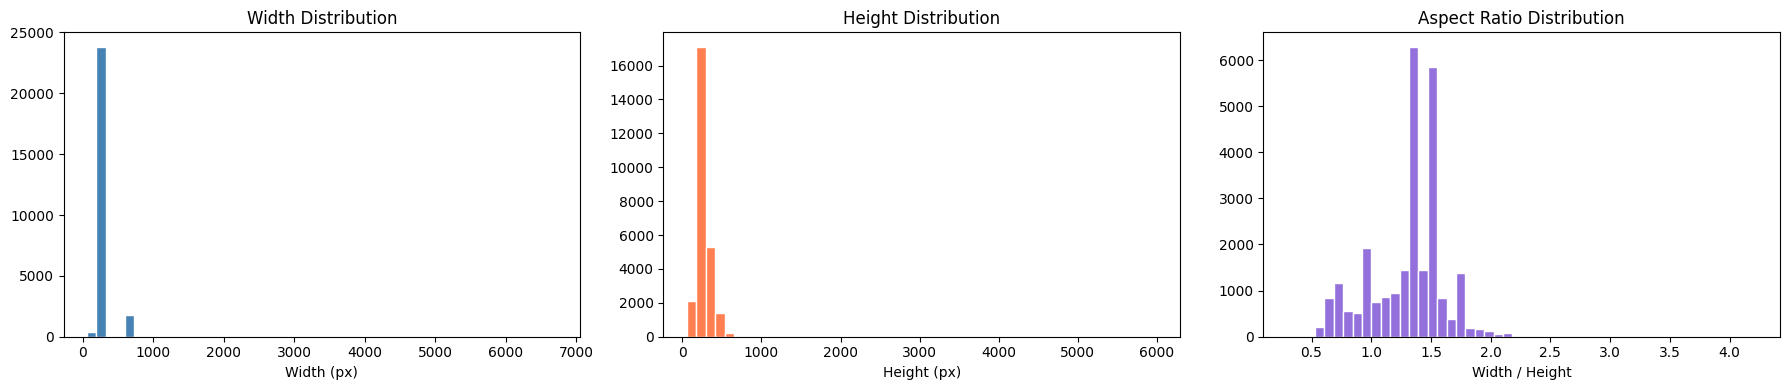

Width  - median: 300, mean: 320, range: [60, 6720]
Height - median: 225, mean: 253, range: [57, 6000]


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(stats_df["width"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (px)")

axes[1].hist(stats_df["height"], bins=50, color="coral", edgecolor="white")
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (px)")

axes[2].hist(stats_df["aspect_ratio"], bins=50, color="mediumpurple", edgecolor="white")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].set_xlabel("Width / Height")

plt.tight_layout()
plt.show()

print(f"Width  - median: {stats_df['width'].median():.0f}, mean: {stats_df['width'].mean():.0f}, range: [{stats_df['width'].min()}, {stats_df['width'].max()}]")
print(f"Height - median: {stats_df['height'].median():.0f}, mean: {stats_df['height'].mean():.0f}, range: [{stats_df['height'].min()}, {stats_df['height'].max()}]")

## 5. Data Quality

In [9]:
corrupted = 0
too_small = 0
grayscale_count = 0
total = len(df)

for _, row in df.iterrows():
    try:
        img = Image.open(row["path"])
        img.verify()  # check for corruption
        img = Image.open(row["path"])  # reopen after verify
        w, h = img.size
        if w < 64 or h < 64:
            too_small += 1
        if img.mode != "RGB":
            grayscale_count += 1
    except Exception:
        corrupted += 1

print(f"Data quality report ({total} total images):")
print(f"  Corrupted / unreadable: {corrupted}")
print(f"  Too small (< 64x64):    {too_small}")
print(f"  Non-RGB (grayscale/RGBA/etc): {grayscale_count}")
print(f"  Clean RGB images:       {total - corrupted - too_small - grayscale_count}")

Data quality report (26179 total images):
  Corrupted / unreadable: 0
  Too small (< 64x64):    5
  Non-RGB (grayscale/RGBA/etc): 51
  Clean RGB images:       26123


## 6. Augmentation Preview

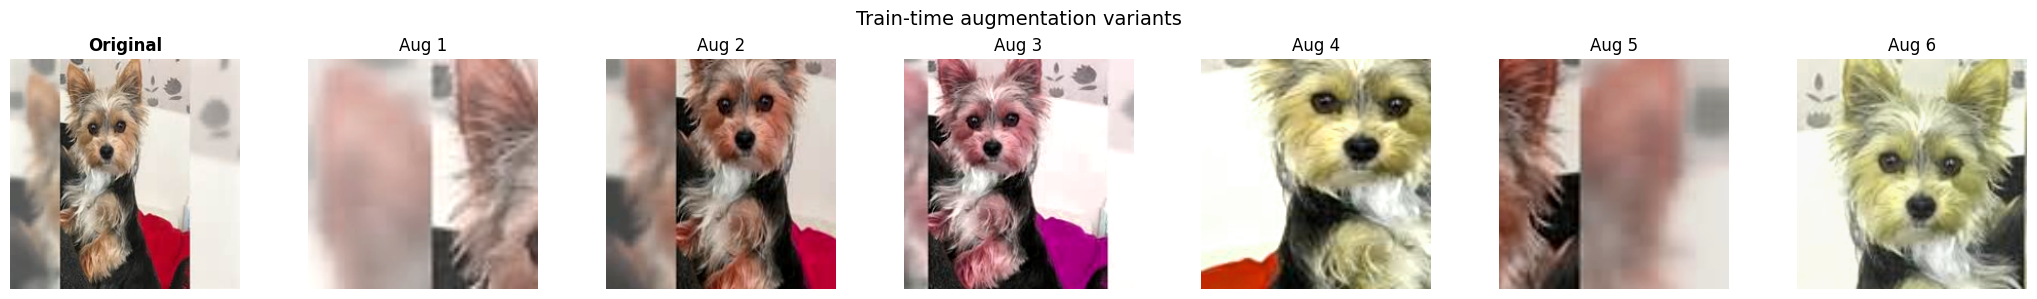

In [10]:
# Pick a sample image
sample_path = df[df["class"] == "dog"]["path"].iloc[0]
sample_img = Image.open(sample_path).convert("RGB")

# Train-time augmentation pipeline
aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
])

fig, axes = plt.subplots(1, 7, figsize=(21, 3))
axes[0].imshow(sample_img.resize((224, 224)))
axes[0].set_title("Original", fontweight="bold")
axes[0].axis("off")

for i in range(1, 7):
    augmented = aug_transform(sample_img)
    axes[i].imshow(augmented)
    axes[i].set_title(f"Aug {i}")
    axes[i].axis("off")

plt.suptitle("Train-time augmentation variants", fontsize=14)
plt.tight_layout()
plt.show()